In [1]:
from myutils import cache, clean_all_cache

from src import *
from glob import glob

from src.fisherinfo import FisherInformation, ApproxFisherInformation, FrequencyCFI

from matplotlib.ticker import AutoMinorLocator, ScalarFormatter

In [2]:
c1 = '#1f77b4'
c2 = '#2ca02c'

red = '#d62728'

width = 8.5 / 2.54 #inches

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

In [3]:
clean_all_cache()

done


In [4]:
@cache
def read_est(A):
    files = [
        f'__estimates__/0noise/spade_{A}px/spade_{A}px_' + 'f{}_d0.npz',
        f'__estimates__/0noise/di_{A}px/di_{A}px_' + 'f{}_d0.npz'
    ]

    di_means, di_vars, spade_means, spade_vars = [], [], [], []

    for file in files:
        for f in np.linspace(0.1, 0.4, 61):
            c = LoadEstimates(file.format(np.round(f, 5))) 
            if c.metadata.measurement == 'DI':
                di_means.append(c.estimates_a.mean())
                di_vars.append(c.estimates_a.var(ddof=1) * (c.photons.mean() - qCMOS.convert2photons(c.background.mean(), 0)))
            elif c.metadata.measurement == 'SPADE':
                spade_means.append(c.estimates_a.mean())
                spade_vars.append(c.estimates_a.var(ddof=1) * (c.photons.mean() - qCMOS.convert2photons(c.background.mean(), 0)))

    return np.array(di_means), np.array(di_vars), np.array(spade_means), np.array(spade_vars)

cache hit: reading result from cache file
cache hit: reading result from cache file


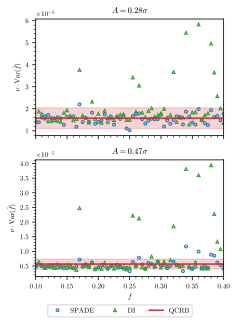

In [153]:
fig, ax = plt.subplots(2, 1, figsize=(width, width * 2.1*0.618), sharex=True)

for ax_ in ax:
    ax_.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax_.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax_.ticklabel_format(style='sci', axis='y')
    ax_.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax_.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax_.set_xlim(0.1, 0.4)
    ax_.set_box_aspect(0.618)



for i, A in enumerate([3, 5]):
    di_means, di_vars, spade_means, spade_vars = read_est(A)
    x_axis = np.linspace(0.1, 0.4, 61)

    line1, = ax[i].plot(x_axis, spade_vars, 
                    marker='o', linestyle='', markersize=3,
                    markeredgecolor=c1, markerfacecolor=(c1, 0.3))

    line2, = ax[i].plot(x_axis, di_vars,
                    marker='^', linestyle='', markersize=3,
                    markeredgecolor=c2, markerfacecolor=(c2, 0.3))
    

for i, A in enumerate([3, 5]):
    x_axis = np.linspace(0.1, 0.4, 3)
    crb = np.array(list(1 / ApproxFisherInformation([A * DMD.PIXEL_SIZE / 2])) * 3)

    crb_line, = ax[i].plot(x_axis, crb, red)

    ax[i].set_ylabel(r'$\nu\cdot{\rm Var}(\hat{f})$')
    ax[i].set_title(rf'$A = {np.round(A * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$')

    ax[i].fill_between(x_axis, 0.7 * np.array(crb), 1.3 * np.array(crb), color=red, alpha=0.2)


ax[1].set_xlabel(r'$f$')


fig.legend([line1, line2, crb_line], ['SPADE', 'DI', 'QCRB'], ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.savefig('ideal.pdf')
plt.show()

cache hit: reading result from cache file
cache hit: reading result from cache file


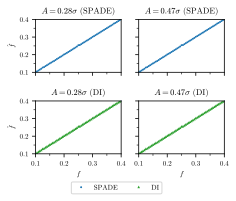

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(width, width*0.8), sharex=True, sharey=True)

for A in (3, 5):
    if A == 3:
        ax_spade = ax1
        ax_di = ax3
    else:
        ax_spade = ax2
        ax_di = ax4

    x_axis = np.linspace(0.1, 0.4, 61)

    di_means, di_vars, spade_means, spade_vars = read_est(A)

    line1, = ax_spade.plot(x_axis, spade_means, 
                    marker='o', linestyle='', markersize=1,
                    markeredgecolor=c1, markerfacecolor=c1)

    line2, = ax_di.plot(x_axis, di_means,
                    marker='^', linestyle='', markersize=1,
                    markeredgecolor=c2, markerfacecolor=c1)


from matplotlib.ticker import AutoMinorLocator
for ax in (ax1, ax2, ax3, ax4):
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y')
    ax.set_xlim(0.1, 0.4)
    ax.set_ylim(0.1, 0.4)

    ax.set_box_aspect(0.618)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

ax3.set_xlabel(r'$f$')
ax4.set_xlabel(r'$f$')

ax1.set_ylabel(r'$\hat f$')
ax3.set_ylabel(r'$\hat f$')

ax1.set_title(rf'$A = {np.round(3 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$ (SPADE)')
ax2.set_title(rf'$A = {np.round(5 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$ (SPADE)')

ax3.set_title(rf'$A = {np.round(3 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$ (DI)')
ax4.set_title(rf'$A = {np.round(5 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$ (DI)')

ax1.set_xticks(np.linspace(0.1, 0.4, 4))
ax1.set_yticks(np.linspace(0.1, 0.4, 4))

# for ax in (ax1, ax2, ax3, ax4):
#     ax.plot([0.1, 0.4], [0.1, 0.4], 'r:')

fig.legend([line1, line2], ['SPADE', 'DI'], ncol=2, loc='lower center', bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
# plt.savefig('mean.pdf')
plt.show()

In [4]:
c_spade = LoadEstimates(rf'__estimates__/noisy/spade_5px/spade_5px_f0.2_d{0}.npz')
c_di = LoadEstimates(rf'__estimates__/noisy/di_5px/di_5px_f0.2_d{0}.npz')

spade_pn = c_spade.photons.mean() - qCMOS.convert2photons(c_spade.background, 0).mean()
di_pn = c_di.photons.mean() - qCMOS.convert2photons(c_di.background, 0).mean()

def read_noisy_est():
    spade_est, di_est = [], []
    spade_b, di_b = [], []
    for d in np.arange(0, 101, 2):
        spade_c = LoadEstimates(rf'__estimates__/noisy/spade_5px/spade_5px_f0.2_d{d}.npz')
        di_c = LoadEstimates(rf'__estimates__/noisy/di_5px/di_5px_f0.2_d{d}.npz')

        spade_est.append(spade_c.estimates_a)
        di_est.append(di_c.estimates_a)

        spade_b.append(spade_c.background.mean())
        di_b.append(di_c.background.mean())

    return np.array(spade_est).mean(-1), \
           np.array(di_est).mean(-1), \
           np.array(spade_est).var(-1, ddof=1) * spade_pn, \
           np.array(di_est).var(-1, ddof=1) * di_pn, \
           qCMOS.convert2photons(np.array(spade_b)) / spade_pn, \
           qCMOS.convert2photons(np.array(di_b)) / di_pn


spade_means, di_means, spade_vars, di_vars, spade_b, di_b = read_noisy_est()

dicfi =  lambda b: FrequencyCFI(DI).cal(0.2, 5*DMD.PIXEL_SIZE/2, [b, 4.6])
spadecfi =  lambda b: FrequencyCFI(BiSPADE).cal(0.2, 5*DMD.PIXEL_SIZE/2, [b])

b = np.linspace(1e-10, 0.1, 300)
ratio = np.array([dicfi(_b) / spadecfi(_b) for _b in b])

di_crb, spade_crb = 1/np.array([dicfi(_b) for _b in di_b]), 1/np.array([spadecfi(_b) for _b in spade_b])

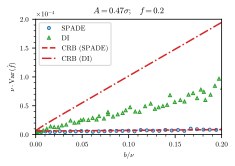

In [5]:
plt.figure(figsize=(width, width))

plt.plot(spade_b, spade_vars, color='#1f77b4', marker='o', 
         linestyle='', markersize=3, 
         markeredgecolor='#1f77b4', markerfacecolor=('#1f77b4', 0.3),
         label='SPADE')

plt.plot(di_b, di_vars, color='#2ca02c', marker='^', 
         linestyle='', markersize=3, 
         markeredgecolor='#2ca02c', markerfacecolor=('#2ca02c', 0.3),
         label='DI')

plt.plot(spade_b, spade_crb, linestyle='--', color='#d62728', label='CRB (SPADE)')
plt.plot(di_b, di_crb, linestyle='-.', color='#d62728', label='CRB (DI)')

plt.xlabel(r'$b/\nu$')
plt.ylabel(r'$\nu\cdot{\rm Var\,}(\hat f)$')

plt.legend(loc='best')

plt.gca().xaxis.set_minor_locator(AutoMinorLocator(5))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(5))


formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))

plt.gca().yaxis.set_major_formatter(formatter)
plt.xlim(0, 0.2)
plt.ylim(0, 2e-4)

plt.xticks(np.arange(0, 0.2001, 0.05))
plt.yticks(np.arange(0, 2.001, 0.5) * 1e-4)

plt.gca().set_box_aspect(0.618)

plt.title(r'$A=0.47\sigma;\quad f=0.2$')

# plt.savefig('noisy.pdf')
plt.show()


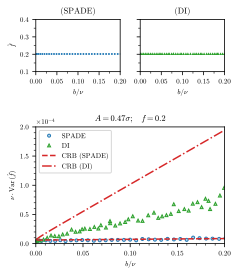

In [137]:
fig = plt.figure(figsize=(width, width*1.25))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax2.tick_params(axis='y', labelleft=False)

ax3 = fig.add_subplot(gs[1, :])

ax1.plot(spade_b, spade_means, marker='o', linestyle='', markersize=1, 
         markeredgecolor=c1, markerfacecolor=c1)

ax2.plot(di_b, di_means, marker='^', linestyle='', markersize=1, 
         markeredgecolor=c2, markerfacecolor=c2)

ax1.set_ylabel(r'$\hat f$')
ax1.set_yticks(np.linspace(0.1, 0.4, 4))

ax1.set_title('(SPADE)')
ax2.set_title('(DI)')

for ax_ in (ax1, ax2, ax3):
    ax_.set_box_aspect(0.618)
    ax_.set_xlim(0, 0.2)
    ax_.set_xlabel(r'$b/\nu$')
    
    if not ax_ == ax3:
        ax_.set_ylim(0.1, 0.4)
        ax_.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax_.yaxis.set_minor_locator(AutoMinorLocator(2))

    else:
        ax_.set_ylim(0, 2e-4)
        ax_.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_.yaxis.set_minor_locator(AutoMinorLocator(5))



ax3.plot(spade_b, spade_vars, color=c1, marker='o', 
         linestyle='', markersize=3, 
         markeredgecolor=c1, markerfacecolor=(c1, 0.3),
         label='SPADE')

ax3.plot(di_b, di_vars, color=c2, marker='^', 
         linestyle='', markersize=3, 
         markeredgecolor=c2, markerfacecolor=(c2, 0.3),
         label='DI')

ax3.plot(spade_b, spade_crb, linestyle='--', color=red, label='CRB (SPADE)')
ax3.plot(di_b, di_crb, linestyle='-.', color=red, label='CRB (DI)')

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))

ax3.yaxis.set_major_formatter(formatter)
ax3.set_xticks(np.linspace(0, 0.2, 5))
ax3.set_yticks(np.arange(0, 2.001, 0.5) * 1e-4)

ax3.set_title(r'$A=0.47\sigma;\quad f=0.2$')
ax3.set_ylabel(r'$\nu\cdot{\rm Var\,}(\hat f)$')
ax3.legend(loc='best')

plt.tight_layout()
plt.savefig('noisy.pdf')
plt.show()
